In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt


In [2]:
# Load and display JSON file
with open('last_experiments/mu_F_1.3_n_most_violated_constraints_10/run_info.json', 'r') as f:
    data = json.load(f)

# Display the JSON data with pretty formatting
import pprint
pprint.pprint(data)


{'c1_constraints_added_per_iteration': [88920,
                                        10269,
                                        2348,
                                        1670,
                                        754,
                                        331,
                                        166,
                                        134,
                                        21,
                                        10,
                                        1,
                                        0],
 'c2_constraints_added_per_iteration': [96958,
                                        47699,
                                        28496,
                                        15881,
                                        8237,
                                        2788,
                                        1985,
                                        103,
                                        0,
                                        0,
  

In [3]:
import os
import glob
from pathlib import Path

def load_all_experiment_data():
    """
    Load all run_info.json files from experiment folders and parse into DataFrame
    """
    all_data = []
    
    # Define the experiment folders to search
    experiment_folders = [
        'last_experiments',
        'last_experiments_debug_mode', 
        'final_results'
    ]
    
    for folder in experiment_folders:
        if os.path.exists(folder):
            print(f"Processing folder: {folder}")
            
            # Find all run_info.json files recursively
            json_files = glob.glob(f"{folder}/**/run_info.json", recursive=True)
            
            for json_file in json_files:
                try:
                    # Load JSON data
                    with open(json_file, 'r') as f:
                        data = json.load(f)
                    
                    # Extract folder structure info for parameter identification
                    path_parts = Path(json_file).parts
                    experiment_folder = path_parts[0]  # e.g., 'last_experiments'
                    param_folder = path_parts[1]       # e.g., 'mu_F_1.3_n_most_violated_constraints_10'
                    
                    # Parse parameters from folder name
                    params = parse_folder_name(param_folder)
                    
                    # Create a flattened record
                    record = {
                        'experiment_folder': experiment_folder,
                        'param_folder': param_folder,
                        'json_file_path': json_file,
                        **params,  # Add parsed parameters
                        **flatten_dict(data, prefix='')  # Add all JSON data with flattened keys
                    }
                    
                    all_data.append(record)
                    
                except Exception as e:
                    print(f"Error loading {json_file}: {e}")
    
    # Convert to DataFrame
    df = pd.DataFrame(all_data)
    return df

def parse_folder_name(folder_name):
    """
    Parse experiment parameters from folder name
    e.g., 'mu_F_1.3_n_most_violated_constraints_10' -> {'mu_F': 1.3, 'n_most_violated_constraints': 10}
    """
    params = {}
    parts = folder_name.split('_')
    
    i = 0
    while i < len(parts):
        if i < len(parts) - 1:
            # Look for parameter patterns
            if parts[i] == 'mu' and parts[i+1] == 'F':
                params['mu_F'] = float(parts[i+2])
                i += 3
            elif parts[i] == 'n' and parts[i+1] == 'most' and parts[i+2] == 'violated' and parts[i+3] == 'constraints':
                params['n_most_violated_constraints'] = int(parts[i+4])
                i += 5
            elif parts[i] == 'max' and parts[i+1] == 'constraint' and parts[i+2] == 'addition':
                params['max_constraint_addition'] = int(parts[i+3])
                i += 4
            else:
                i += 1
        else:
            i += 1
    
    return params

def flatten_dict(d, prefix=''):
    """
    Flatten nested dictionary with dot notation
    """
    items = []
    for k, v in d.items():
        new_key = f"{prefix}{k}" if prefix else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, f"{new_key}_").items())
        elif isinstance(v, list):
            # For lists, we'll store as is but also create summary stats
            items.append((new_key, v))
            if len(v) > 0 and all(isinstance(x, (int, float)) for x in v):
                items.append((f"{new_key}_mean", np.mean(v)))
                items.append((f"{new_key}_std", np.std(v)))
                items.append((f"{new_key}_min", np.min(v)))
                items.append((f"{new_key}_max", np.max(v)))
                items.append((f"{new_key}_final", v[-1] if v else None))
        else:
            items.append((new_key, v))
    return dict(items)

# Load all data
print("Loading all experiment data...")
df = load_all_experiment_data()
print(f"Loaded {len(df)} experiments")
print(f"Columns: {list(df.columns)}")
df.head(44)


Loading all experiment data...
Processing folder: last_experiments
Processing folder: last_experiments_debug_mode
Processing folder: final_results
Loaded 44 experiments
Columns: ['experiment_folder', 'param_folder', 'json_file_path', 'mu_F', 'n_most_violated_constraints', 'gamma_parameters_max_dist', 'gamma_parameters_gamma_constant', 'gamma_parameters_alpha_0', 'gamma_parameters_alpha_1', 'gamma_parameters_alpha_2', 'projection_parameters_delta', 'projection_parameters_sigma', 'optimization_parameters_solution_method', 'optimization_parameters_row_generation', 'optimization_parameters_n_most_violated_constraints', 'optimization_parameters_max_row_generation_iterations', 'optimization_parameters_N', 'optimization_parameters_lam', 'optimization_parameters_mu_F', 'optimization_parameters_d_bar_organ_1', 'optimization_parameters_d_bar_F_organ_1', 'optimization_parameters_d_bar_organ_2', 'optimization_parameters_d_bar_F_organ_2', 'optimization_parameters_d_bar_organ_3', 'optimization_param

,experiment_folder,param_folder,json_file_path,mu_F,n_most_violated_constraints,gamma_parameters_max_dist,gamma_parameters_gamma_constant,gamma_parameters_alpha_0,gamma_parameters_alpha_1,gamma_parameters_alpha_2,...,c2_constraints_added_per_iteration,c2_constraints_added_per_iteration_mean,c2_constraints_added_per_iteration_std,c2_constraints_added_per_iteration_min,c2_constraints_added_per_iteration_max,c2_constraints_added_per_iteration_final,solve_time_seconds,peak_memory_mb,max_constraint_addition,optimization_parameters_max_constraint_addition
0,last_experiments,mu_F_1.5_n_most_violated_constraints_10,last_experiments/mu_F_1.5_n_most_violated_cons...,1.500,10,10.0,0.15,0.029276,-0.001351,0.012826,...,"[26615, 3071, 894, 21, 0, 0]",5100.166667,9682.619677,0,26615,0,4799.923,8374.559,NaN,NaN
1,last_experiments,mu_F_1.3_n_most_violated_constraints_10,last_experiments/mu_F_1.3_n_most_violated_cons...,1.300,10,10.0,0.15,0.029276,-0.001351,0.012826,...,"[96958, 47699, 28496, 15881, 8237, 2788, 1985,...",16845.583333,28009.766682,0,96958,0,6832.470,8353.973,NaN,NaN
2,last_experiments,mu_F_1.5_n_most_violated_constraints_20,last_experiments/mu_F_1.5_n_most_violated_cons...,1.500,20,10.0,0.15,0.029276,-0.001351,0.012826,...,"[46299, 11107, 1483, 57, 0, 0]",9824.333333,16783.226921,0,46299,0,4844.846,8324.680,NaN,NaN
3,last_experiments,mu_F_1.7_n_most_violated_constraints_100,last_experiments/mu_F_1.7_n_most_violated_cons...,1.700,100,10.0,0.15,0.029276,-0.001351,0.012826,...,"[59654, 254, 49, 0, 0]",11991.400000,23831.484483,0,59654,0,4843.474,8328.707,NaN,NaN
4,last_experiments,mu_F_1.3_n_most_violated_constraints_20,last_experiments/mu_F_1.3_n_most_violated_cons...,1.300,20,10.0,0.15,0.029276,-0.001351,0.012826,...,"[180812, 65880, 42135, 6139, 912, 80, 0, 0]",36994.750000,59053.096038,0,180812,0,6269.954,8403.484,NaN,NaN
5,last_experiments,mu_F_1.35_n_most_violated_constraints_20,last_experiments/mu_F_1.35_n_most_violated_con...,1.350,20,10.0,0.15,0.029276,-0.001351,0.012826,...,"[138374, 45013, 14842, 7619, 673, 120, 34, 0, 0]",22963.888889,43084.251981,0,138374,0,6014.670,8720.422,NaN,NaN
6,last_experiments,mu_F_1.35_n_most_violated_constraints_10,last_experiments/mu_F_1.35_n_most_violated_con...,1.350,10,10.0,0.15,0.029276,-0.001351,0.012826,...,"[76005, 38021, 19124, 9085, 5577, 2346, 559, 0...",16746.333333,23999.034869,0,76005,0,5921.796,8692.898,NaN,NaN
7,last_experiments,mu_F_1.4_n_most_violated_constraints_100,last_experiments/mu_F_1.4_n_most_violated_cons...,1.400,100,10.0,0.15,0.029276,-0.001351,0.012826,...,"[356944, 48674, 1917, 38, 0, 0]",67928.833333,130445.324023,0,356944,0,5556.826,9073.031,NaN,NaN
8,last_experiments,mu_F_1.325_n_most_violated_constraints_100,last_experiments/mu_F_1.325_n_most_violated_co...,1.325,100,10.0,0.15,0.029276,-0.001351,0.012826,...,"[614743, 86060, 9872, 218, 0, 0, 0]",101556.142857,211530.893554,0,614743,0,6308.370,9155.211,NaN,NaN
9,last_experiments,mu_F_1.4_n_most_violated_constraints_10,last_experiments/mu_F_1.4_n_most_violated_cons...,1.400,10,10.0,0.15,0.029276,-0.001351,0.012826,...,"[55897, 22791, 14937, 4783, 2131, 245, 53, 0]",12604.625000,18108.999047,0,55897,0,5224.704,8745.129,NaN,NaN


In [4]:
# Remove duplicates: if same mu_F exists in multiple folders, keep only last_experiments
df_cleaned = df.copy()

# For each mu_F value, if it exists in multiple experiment_folders, keep only last_experiments
for mu_f_val in df['mu_F'].unique():
    mu_f_data = df[df['mu_F'] == mu_f_val]
    folders = mu_f_data['experiment_folder'].unique()
    
    if len(folders) > 1 and 'last_experiments' in folders:
        # Remove entries from other folders for this mu_F
        indices_to_remove = df[(df['mu_F'] == mu_f_val) & (df['experiment_folder'] != 'last_experiments')].index
        df_cleaned = df_cleaned.drop(indices_to_remove)

print(f"Original data: {len(df)} rows")
print(f"Cleaned data: {len(df_cleaned)} rows")

# Verify the cleaning worked
print("\nμF = 1.3 data after cleaning:")
mu_f_1_3_cleaned = df_cleaned[df_cleaned['mu_F'] == 1.3]
print(mu_f_1_3_cleaned[['mu_F', 'n_most_violated_constraints', 'total_constraints_added', 'experiment_folder']])

# Update the main dataframe
df = df_cleaned.copy()

Original data: 44 rows
Cleaned data: 28 rows

μF = 1.3 data after cleaning:
    mu_F  n_most_violated_constraints  total_constraints_added  \
1    1.3                           10                   306771   
4    1.3                           20                   482993   
22   1.3                          100                  1734545   

   experiment_folder  
1   last_experiments  
4   last_experiments  
22  last_experiments  


In [5]:
df['final_objective_value'] = df['objective_value_per_iteration'].apply(lambda x: x[-1])

In [6]:
mu_F_and_obj_val_df = df[['mu_F', 'final_objective_value', 'experiment_folder']]

In [7]:
mu_F_and_obj_val_df = mu_F_and_obj_val_df[(mu_F_and_obj_val_df['experiment_folder'] == 'last_experiments') | (mu_F_and_obj_val_df['final_objective_value']==0)]

In [8]:
mu_F_and_obj_val_df

,mu_F,final_objective_value,experiment_folder
0,1.500,28.974441,last_experiments
1,1.300,28.974441,last_experiments
2,1.500,28.974441,last_experiments
3,1.700,28.974441,last_experiments
4,1.300,28.974441,last_experiments
5,1.350,28.974441,last_experiments
6,1.350,28.974441,last_experiments
7,1.400,28.974441,last_experiments
8,1.325,28.974441,last_experiments
9,1.400,28.974441,last_experiments


In [9]:
#keep only unique mu_F values
mu_F_and_obj_val_df = mu_F_and_obj_val_df.drop_duplicates(subset=['mu_F'], keep='first')

In [10]:
mu_F_and_obj_val_df = mu_F_and_obj_val_df.sort_values(by='mu_F')
mu_F_and_obj_val_df = mu_F_and_obj_val_df[mu_F_and_obj_val_df['mu_F']*100%10 == 0]

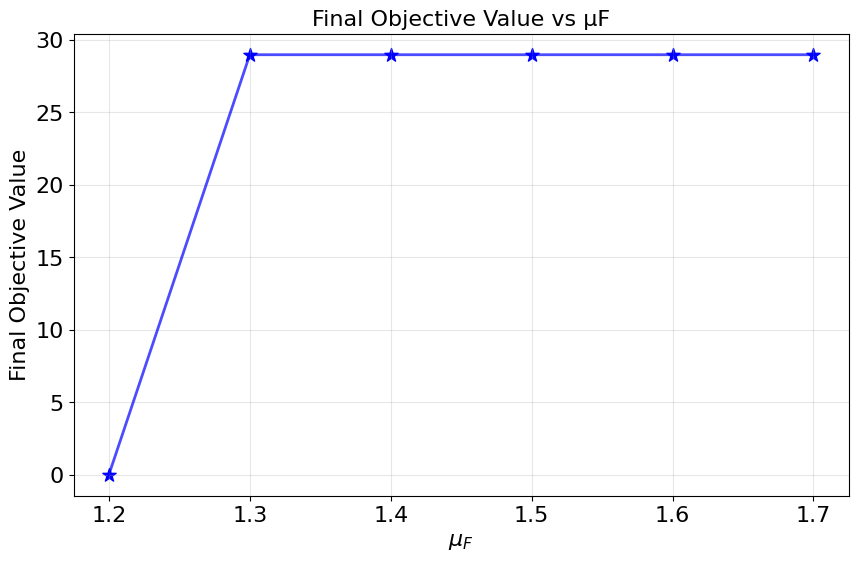

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(mu_F_and_obj_val_df['mu_F'], mu_F_and_obj_val_df['final_objective_value'], marker='*', s=100, c='blue')
plt.plot(mu_F_and_obj_val_df['mu_F'], mu_F_and_obj_val_df['final_objective_value'], 'b-', linewidth=2, alpha=0.7)
plt.xlabel(r'$\mu_F$', fontsize=16)
plt.ylabel('Final Objective Value', fontsize=16)
plt.title('Final Objective Value vs μF', fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('plots/mu_F_and_obj_val_df.png')
plt.show()

In [12]:
df.columns

Index(['experiment_folder', 'param_folder', 'json_file_path', 'mu_F',
       'n_most_violated_constraints', 'gamma_parameters_max_dist',
       'gamma_parameters_gamma_constant', 'gamma_parameters_alpha_0',
       'gamma_parameters_alpha_1', 'gamma_parameters_alpha_2',
       'projection_parameters_delta', 'projection_parameters_sigma',
       'optimization_parameters_solution_method',
       'optimization_parameters_row_generation',
       'optimization_parameters_n_most_violated_constraints',
       'optimization_parameters_max_row_generation_iterations',
       'optimization_parameters_N', 'optimization_parameters_lam',
       'optimization_parameters_mu_F', 'optimization_parameters_d_bar_organ_1',
       'optimization_parameters_d_bar_F_organ_1',
       'optimization_parameters_d_bar_organ_2',
       'optimization_parameters_d_bar_F_organ_2',
       'optimization_parameters_d_bar_organ_3',
       'optimization_parameters_d_bar_F_organ_3',
       'optimization_parameters_eps', 'foun

In [13]:
df_constr_added = df[['mu_F', 'n_most_violated_constraints', 'total_constraints_added', 'c1_constraints_added_per_iteration','c2_constraints_added_per_iteration','solve_time_seconds', 'peak_memory_mb', 'experiment_folder']]
df_constr_added = df_constr_added[(df_constr_added["mu_F"] >= 1.3)]
df_constr_added = df_constr_added[df_constr_added["experiment_folder"]=="last_experiments"]

In [14]:
df_constr_added

,mu_F,n_most_violated_constraints,total_constraints_added,c1_constraints_added_per_iteration,c2_constraints_added_per_iteration,solve_time_seconds,peak_memory_mb,experiment_folder
0,1.500,10,53663,"[21567, 1020, 326, 145, 4, 0]","[26615, 3071, 894, 21, 0, 0]",4799.923,8374.559,last_experiments
1,1.300,10,306771,"[88920, 10269, 2348, 1670, 754, 331, 166, 134,...","[96958, 47699, 28496, 15881, 8237, 2788, 1985,...",6832.470,8353.973,last_experiments
2,1.500,20,105149,"[43017, 2696, 282, 188, 20, 0]","[46299, 11107, 1483, 57, 0, 0]",4844.846,8324.680,last_experiments
3,1.700,100,132055,"[68359, 3680, 36, 23, 0]","[59654, 254, 49, 0, 0]",4843.474,8328.707,last_experiments
4,1.300,20,482993,"[177673, 5096, 2928, 781, 511, 39, 7, 0]","[180812, 65880, 42135, 6139, 912, 80, 0, 0]",6269.954,8403.484,last_experiments
5,1.350,20,348621,"[136075, 3839, 1337, 518, 108, 65, 1, 3, 0]","[138374, 45013, 14842, 7619, 673, 120, 34, 0, 0]",6014.670,8720.422,last_experiments
6,1.350,10,225433,"[68178, 3960, 1239, 661, 254, 211, 148, 65, 0]","[76005, 38021, 19124, 9085, 5577, 2346, 559, 0...",5921.796,8692.898,last_experiments
7,1.400,100,902470,"[482684, 10700, 1034, 439, 40, 0]","[356944, 48674, 1917, 38, 0, 0]",5556.826,9073.031,last_experiments
8,1.325,100,1491921,"[772096, 6843, 1602, 305, 72, 110, 0]","[614743, 86060, 9872, 218, 0, 0, 0]",6308.370,9155.211,last_experiments
9,1.400,10,156465,"[49386, 3295, 1809, 576, 208, 132, 222, 0]","[55897, 22791, 14937, 4783, 2131, 245, 53, 0]",5224.704,8745.129,last_experiments


/var/folders/vm/8dn7pd7j4bn49nd2b27k1kwm0000gn/T/ipykernel_27702/806623121.py:12: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(subset_sorted['n_most_violated_constraints'],


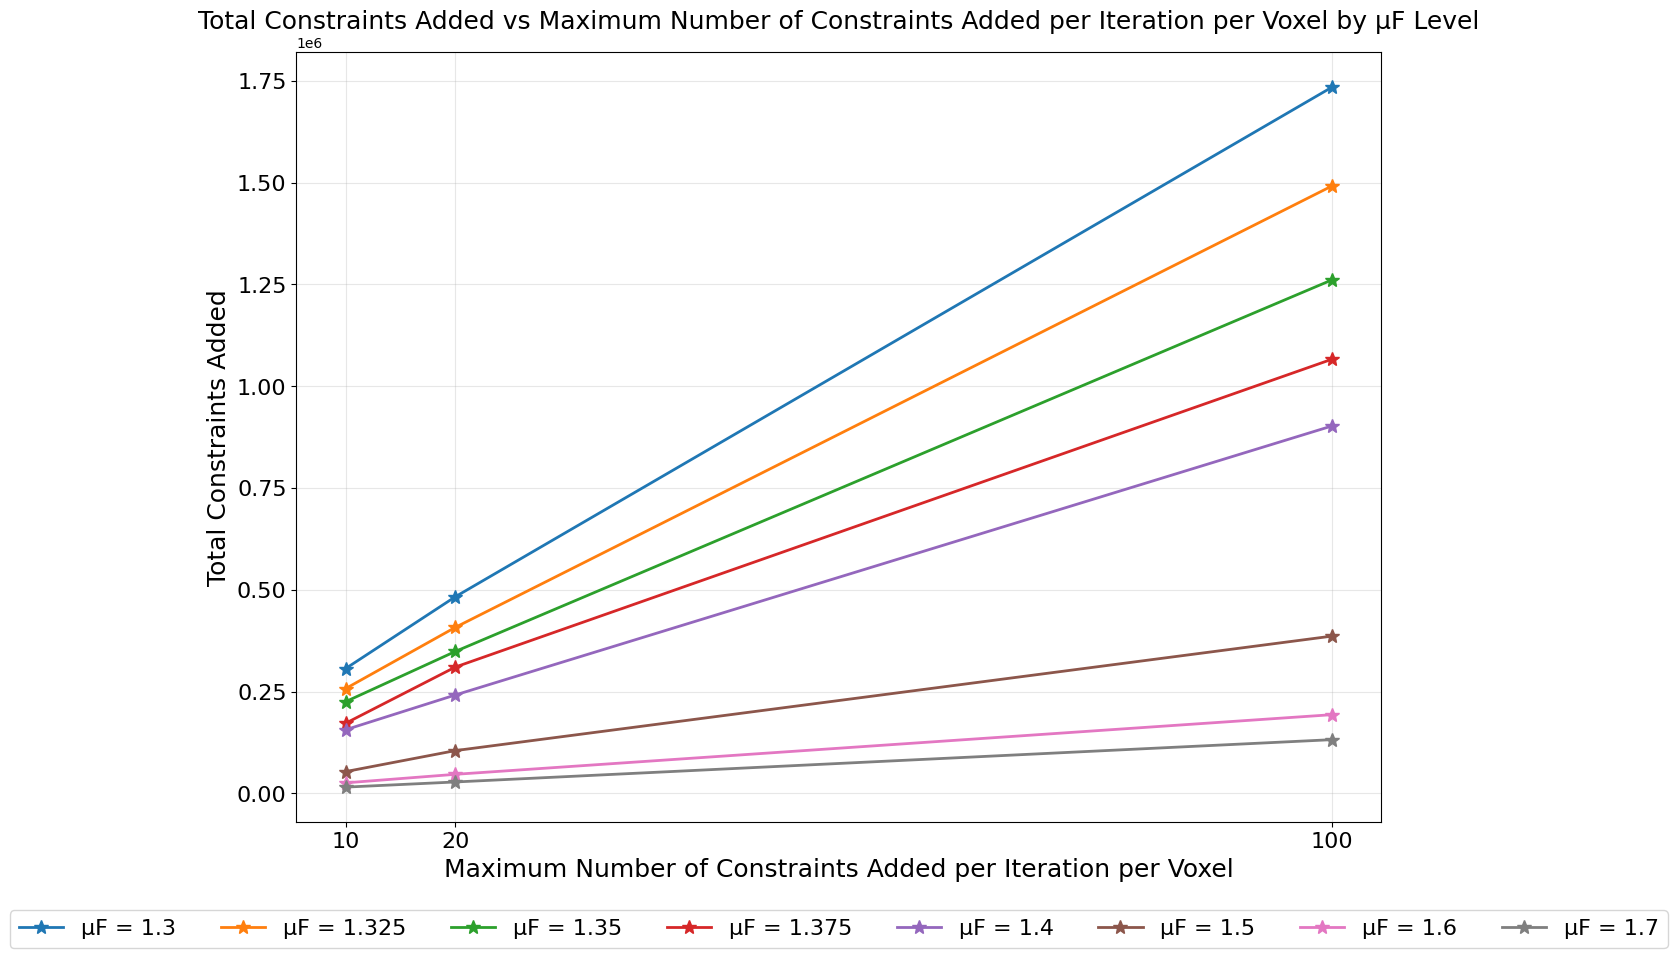

In [15]:
plt.figure(figsize=(14, 10))

# Get unique mu_F values and sort them
mu_F_values = sorted(df_constr_added['mu_F'].unique())

# Create a line plot for each mu_F level
for mu_F in mu_F_values:
    subset = df_constr_added[df_constr_added['mu_F'] == mu_F]
    # Sort by n_most_violated_constraints for proper line connection
    subset_sorted = subset.sort_values('n_most_violated_constraints')
    
    plt.plot(subset_sorted['n_most_violated_constraints'], 
             subset_sorted['total_constraints_added'], 
             'o-', linewidth=2, markersize=10, marker='*', 
             label=f'μF = {mu_F}')

plt.xlabel('Maximum Number of Constraints Added per Iteration per Voxel', fontsize=18)
plt.ylabel('Total Constraints Added', fontsize=18)
plt.title('Total Constraints Added vs Maximum Number of Constraints Added per Iteration per Voxel by μF Level', fontsize=18)
plt.legend(fontsize=16)
plt.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(mu_F_values))
plt.grid(True, alpha=0.3)
plt.xticks(sorted(df['n_most_violated_constraints'].unique()), fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('plots/total_constraints_added_vs_n_most_violated_constraints.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

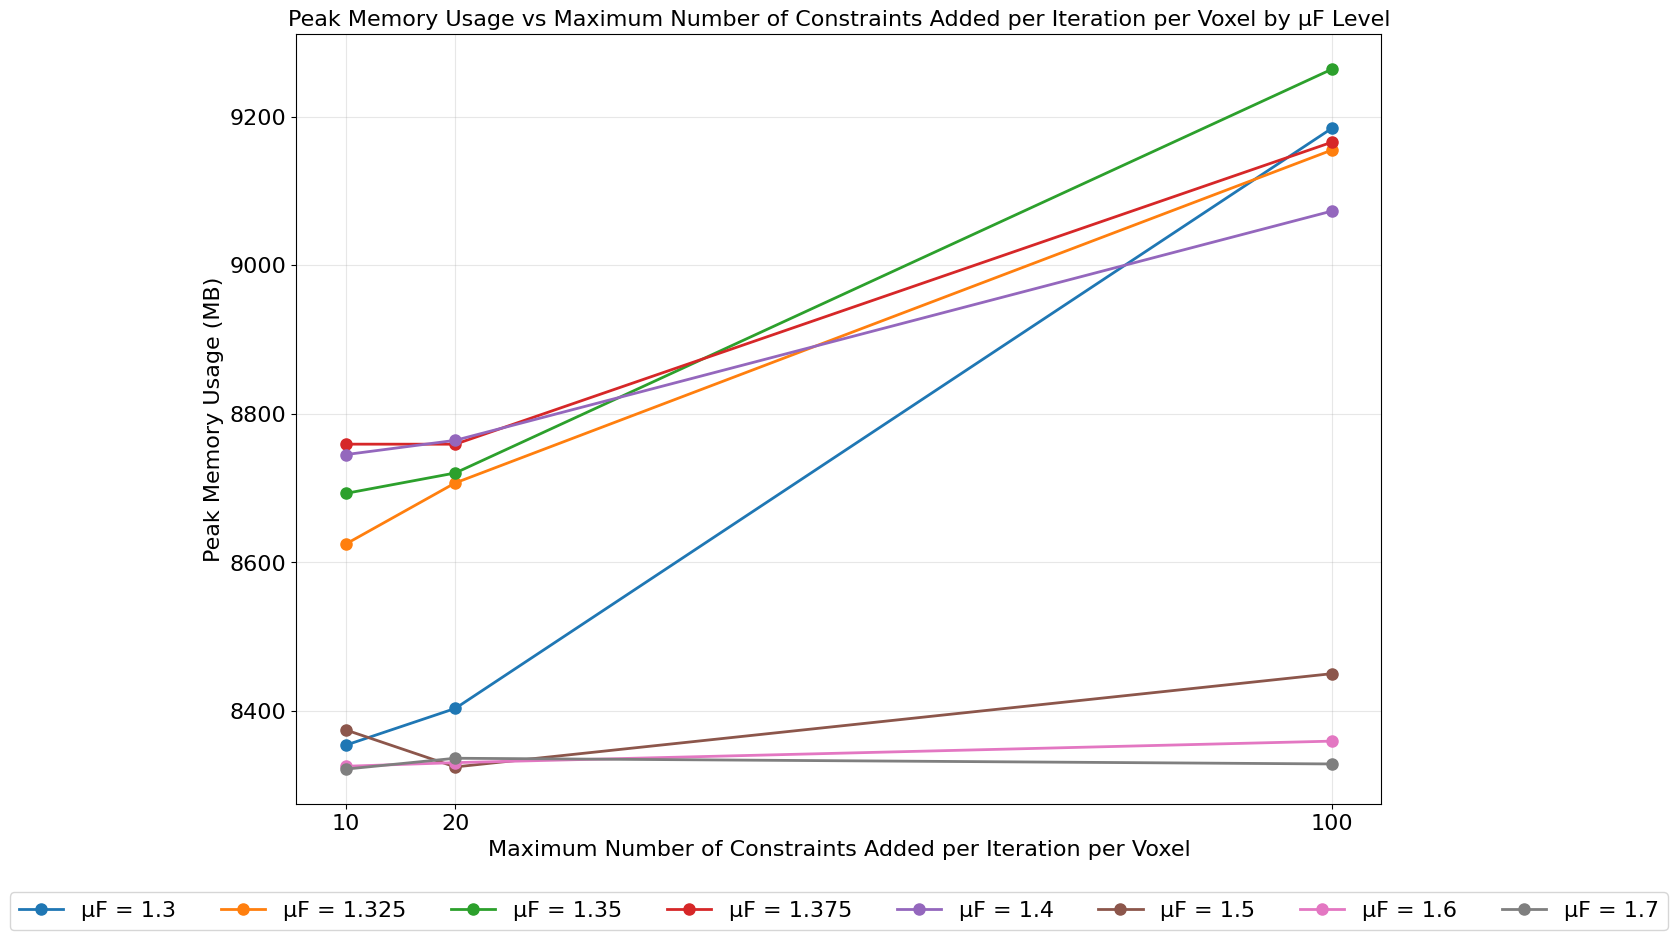

In [16]:
plt.figure(figsize=(14, 10))

# Get unique mu_F values and sort them
mu_F_values = sorted(df_constr_added['mu_F'].unique())

# Create a line plot for each mu_F level
for mu_F in mu_F_values:
    subset = df_constr_added[df_constr_added['mu_F'] == mu_F]
    # Sort by n_most_violated_constraints for proper line connection
    subset_sorted = subset.sort_values('n_most_violated_constraints')
    
    plt.plot(subset_sorted['n_most_violated_constraints'], 
             subset_sorted['peak_memory_mb'], 
             'o-', linewidth=2, markersize=8, 
             label=f'μF = {mu_F}')

plt.xlabel('Maximum Number of Constraints Added per Iteration per Voxel', fontsize=16)
plt.ylabel('Peak Memory Usage (MB)', fontsize=16)
plt.title('Peak Memory Usage vs Maximum Number of Constraints Added per Iteration per Voxel by μF Level', fontsize=16)
plt.legend(fontsize = 16)
plt.legend(fontsize = 16, loc = 'upper center', bbox_to_anchor = (0.5, -0.1), ncol = len(mu_F_values))
plt.grid(True, alpha=0.3)
plt.xticks(sorted(df['n_most_violated_constraints'].unique()), fontsize=16)
plt.yticks(fontsize=16)
plt.savefig(
    'plots/peak_memory_usage_vs_n_most_violated_constraints.png',
    bbox_inches='tight',
    pad_inches=0.1
)
plt.show()

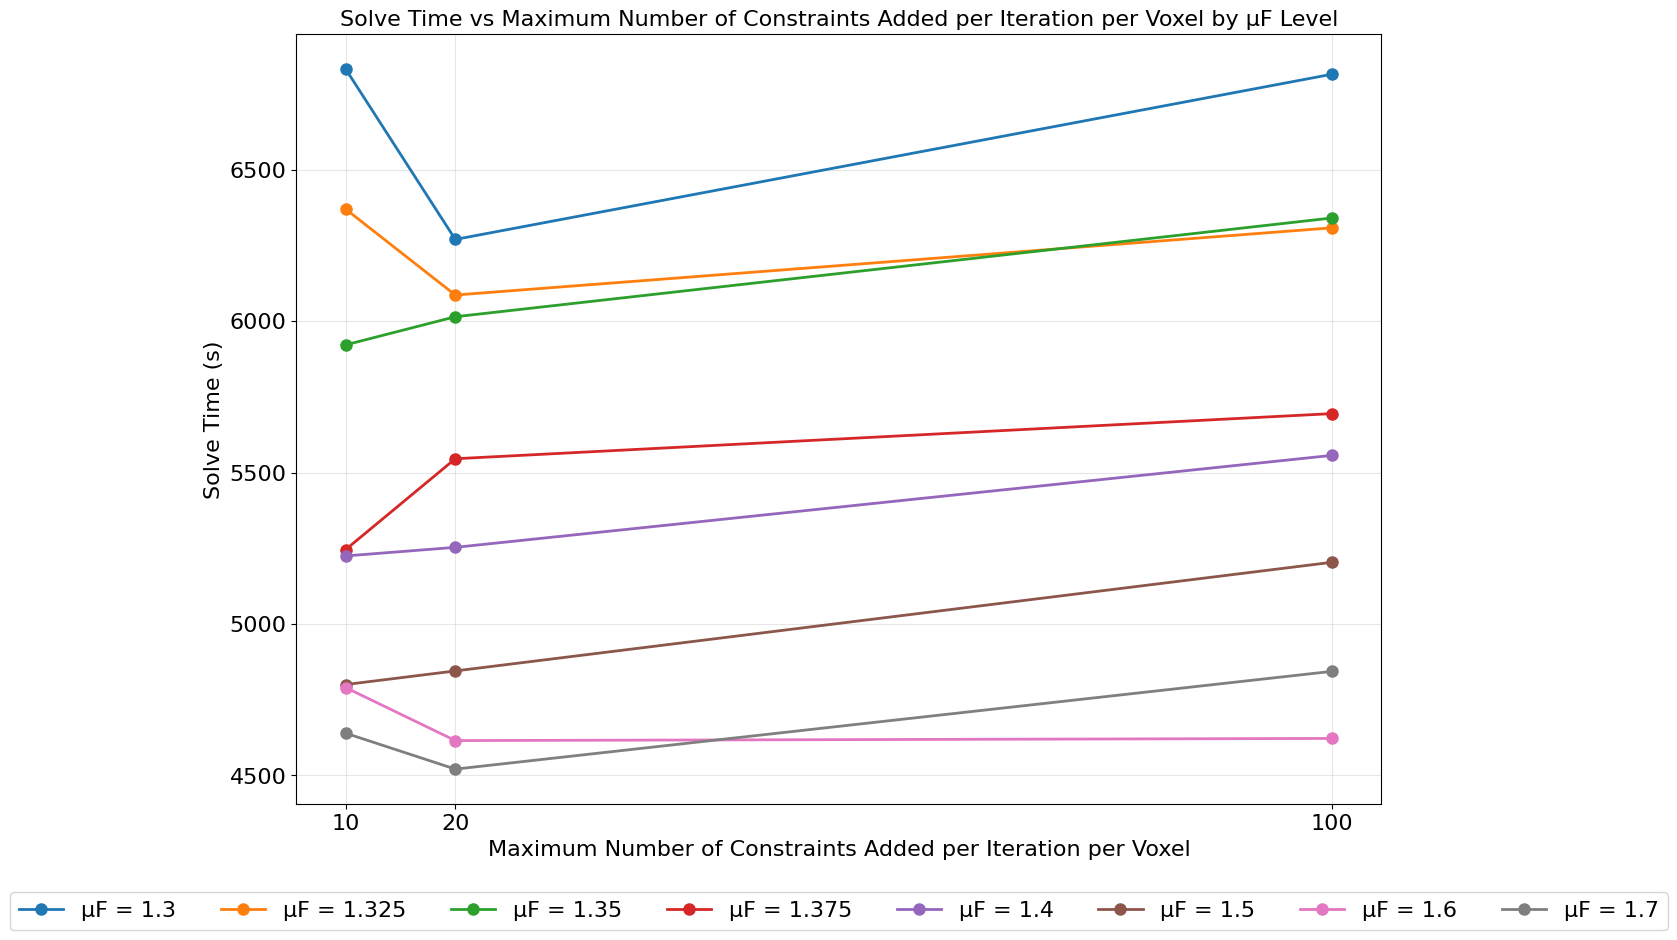

In [17]:
plt.figure(figsize=(14, 10))

# Get unique mu_F values and sort them
mu_F_values = sorted(df_constr_added['mu_F'].unique())

# Create a line plot for each mu_F level
for mu_F in mu_F_values:
    subset = df_constr_added[df_constr_added['mu_F'] == mu_F]
    # Sort by n_most_violated_constraints for proper line connection
    subset_sorted = subset.sort_values('n_most_violated_constraints')
    
    plt.plot(subset_sorted['n_most_violated_constraints'], 
             subset_sorted['solve_time_seconds'], 
             'o-', linewidth=2, markersize=8, 
             label=f'μF = {mu_F}')

plt.xlabel('Maximum Number of Constraints Added per Iteration per Voxel', fontsize=16)
plt.ylabel('Solve Time (s)', fontsize=16)
plt.title('Solve Time vs Maximum Number of Constraints Added per Iteration per Voxel by μF Level', fontsize=16)
plt.legend(fontsize = 16)
plt.legend(fontsize = 16, loc = 'upper center', bbox_to_anchor = (0.5, -0.1), ncol = len(mu_F_values))
plt.grid(True, alpha=0.3)
plt.xticks(sorted(df['n_most_violated_constraints'].unique()), fontsize=16)
plt.yticks(fontsize=16)
plt.savefig(
    'plots/solve_time_vs_n_most_violated_constraints.png',
    bbox_inches='tight',
    pad_inches=0.1
)
plt.show()

In [18]:
df['c2_constraints_added_per_iteration']

0                          [26615, 3071, 894, 21, 0, 0]
1     [96958, 47699, 28496, 15881, 8237, 2788, 1985,...
2                        [46299, 11107, 1483, 57, 0, 0]
3                                [59654, 254, 49, 0, 0]
4           [180812, 65880, 42135, 6139, 912, 80, 0, 0]
5      [138374, 45013, 14842, 7619, 673, 120, 34, 0, 0]
6     [76005, 38021, 19124, 9085, 5577, 2346, 559, 0...
7                       [356944, 48674, 1917, 38, 0, 0]
8                   [614743, 86060, 9872, 218, 0, 0, 0]
9         [55897, 22791, 14937, 4783, 2131, 245, 53, 0]
10                  [99992, 24735, 9781, 4496, 0, 0, 0]
11                            [157397, 10537, 27, 0, 0]
12                      [518475, 61787, 289, 296, 0, 0]
13                [118283, 44156, 19638, 2181, 4, 0, 0]
14    [86637, 32941, 23303, 19087, 7504, 1480, 116, ...
15               [65716, 27637, 12182, 2995, 306, 1, 0]
16    [159447, 56055, 24907, 3391, 834, 188, 0, 0, 2...
17                                   [13800, 290

In [19]:
df_constr_added_c1 = df_constr_added[['mu_F', 'n_most_violated_constraints', 'c1_constraints_added_per_iteration', 'experiment_folder']]
df_constr_added_c1 = df_constr_added_c1.sort_values(by='mu_F')
df_constr_added_c1 = df_constr_added_c1[df_constr_added_c1['mu_F']*100%10 == 0]

df_constr_added_c2 = df_constr_added[['mu_F', 'n_most_violated_constraints', 'c2_constraints_added_per_iteration', 'experiment_folder']]
df_constr_added_c2 = df_constr_added_c2.sort_values(by='mu_F')
df_constr_added_c2 = df_constr_added_c2[df_constr_added_c2['mu_F']*100%10 == 0]

In [20]:
print(df_constr_added_c1)

    mu_F  n_most_violated_constraints  \
1    1.3                           10   
4    1.3                           20   
22   1.3                          100   
7    1.4                          100   
9    1.4                           10   
10   1.4                           20   
0    1.5                           10   
11   1.5                          100   
2    1.5                           20   
20   1.6                          100   
21   1.6                           20   
23   1.6                           10   
17   1.7                           20   
18   1.7                           10   
3    1.7                          100   

                   c1_constraints_added_per_iteration experiment_folder  
1   [88920, 10269, 2348, 1670, 754, 331, 166, 134,...  last_experiments  
4            [177673, 5096, 2928, 781, 511, 39, 7, 0]  last_experiments  
22               [880645, 6845, 1547, 382, 199, 3, 0]  last_experiments  
7                   [482684, 10700, 1034, 439, 

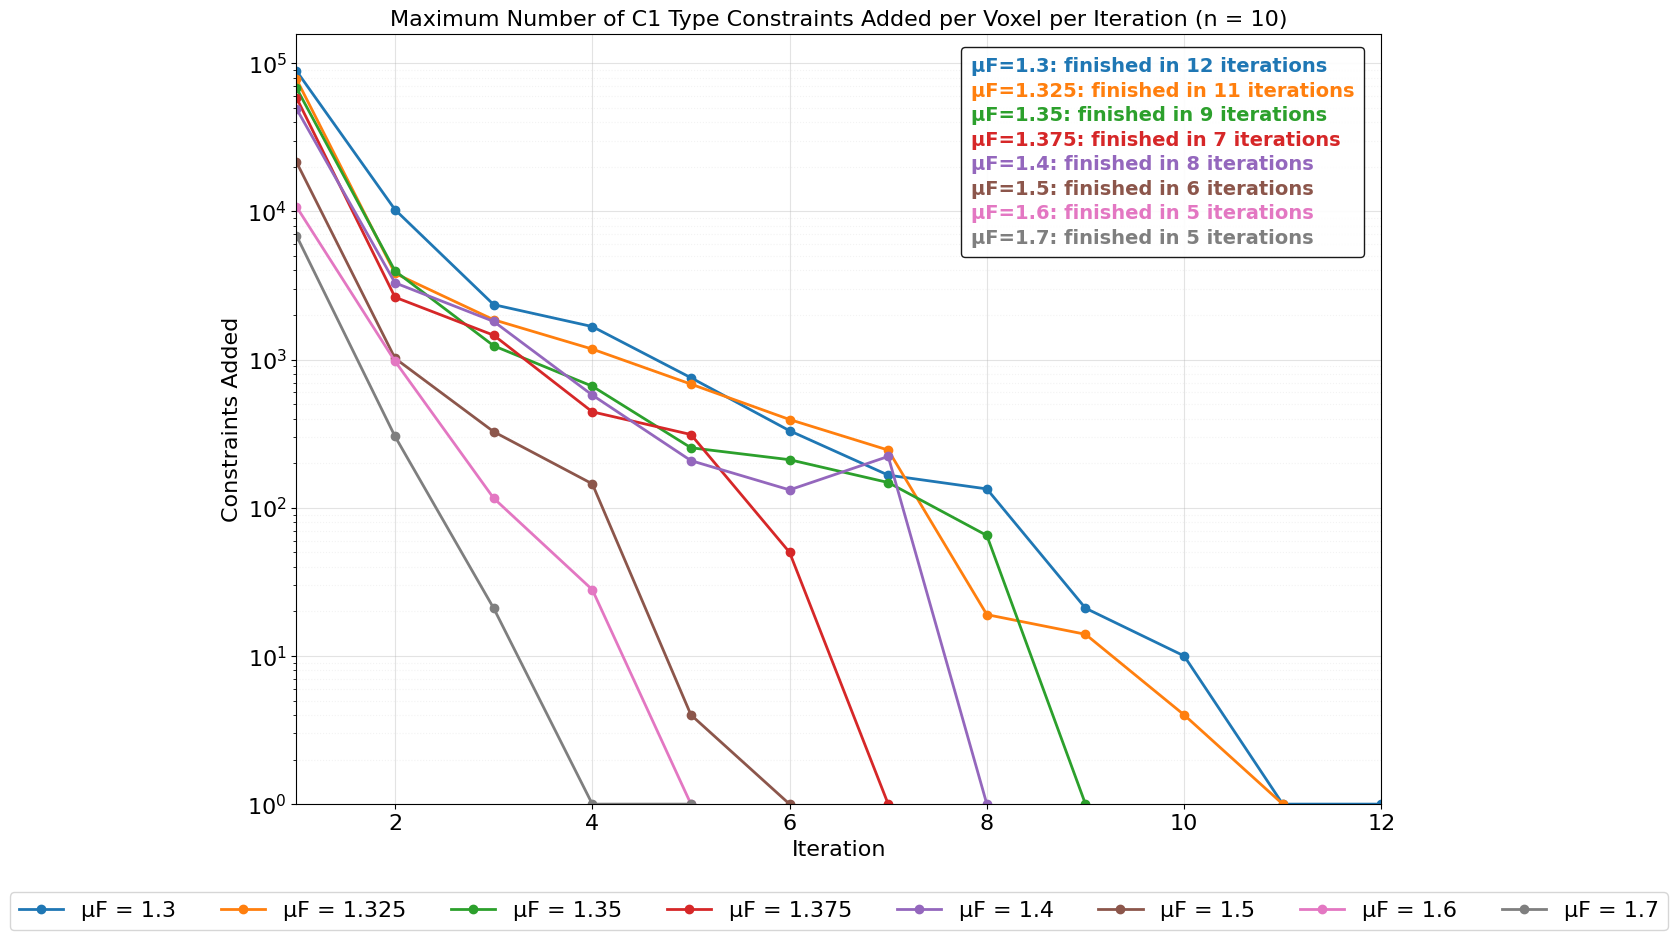

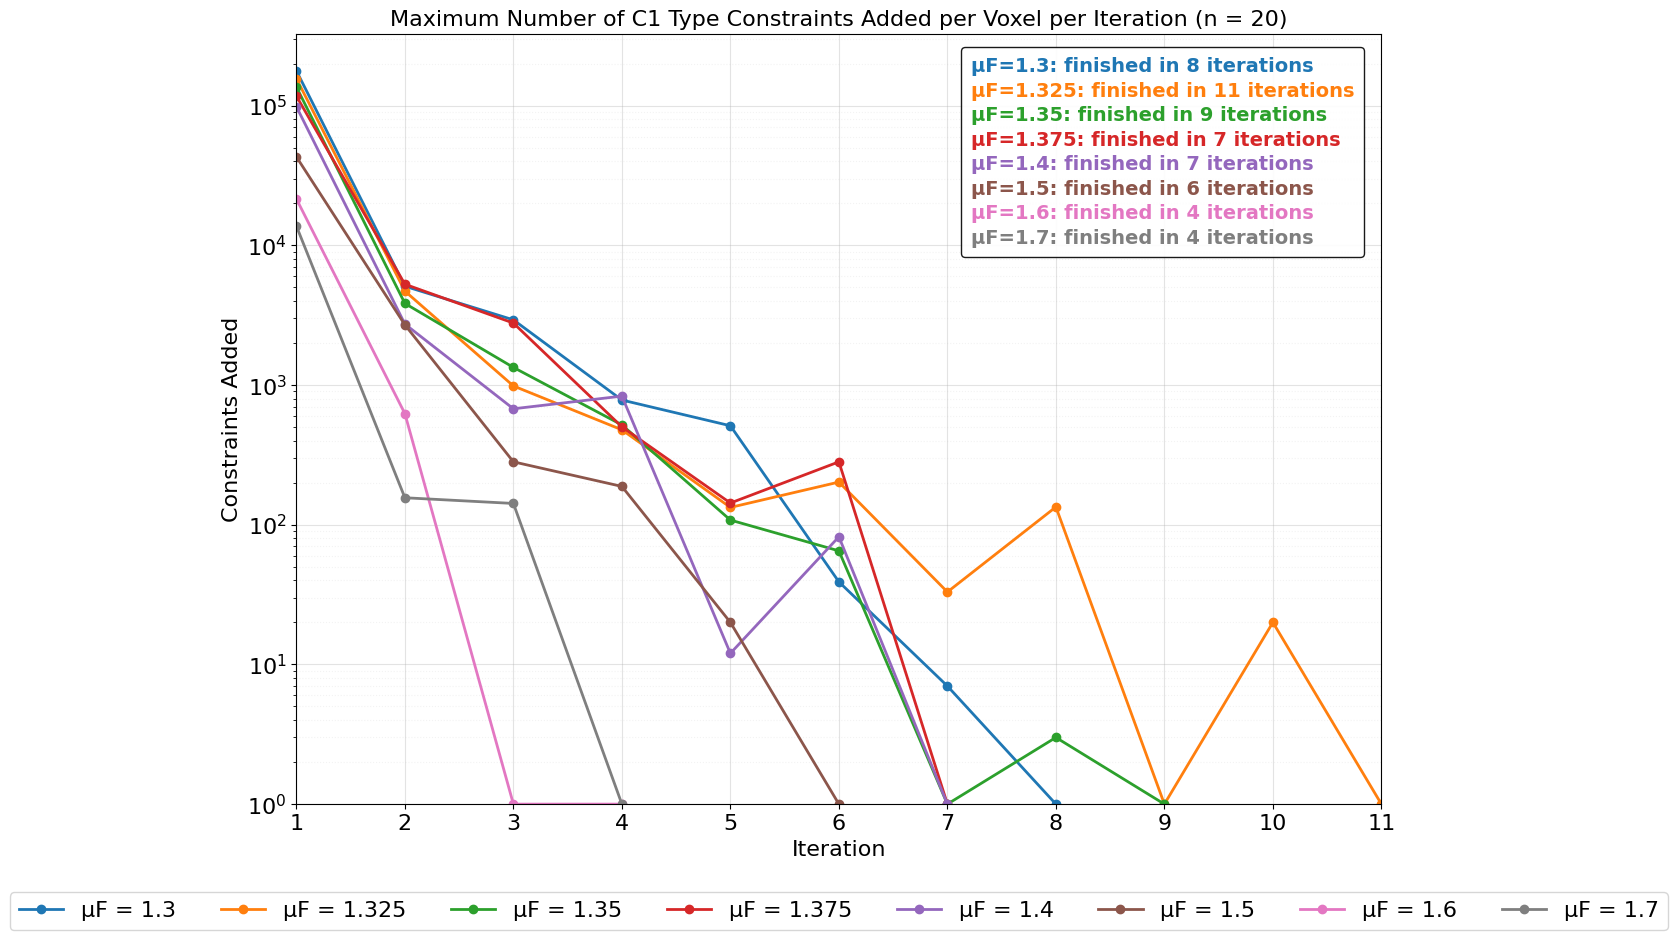

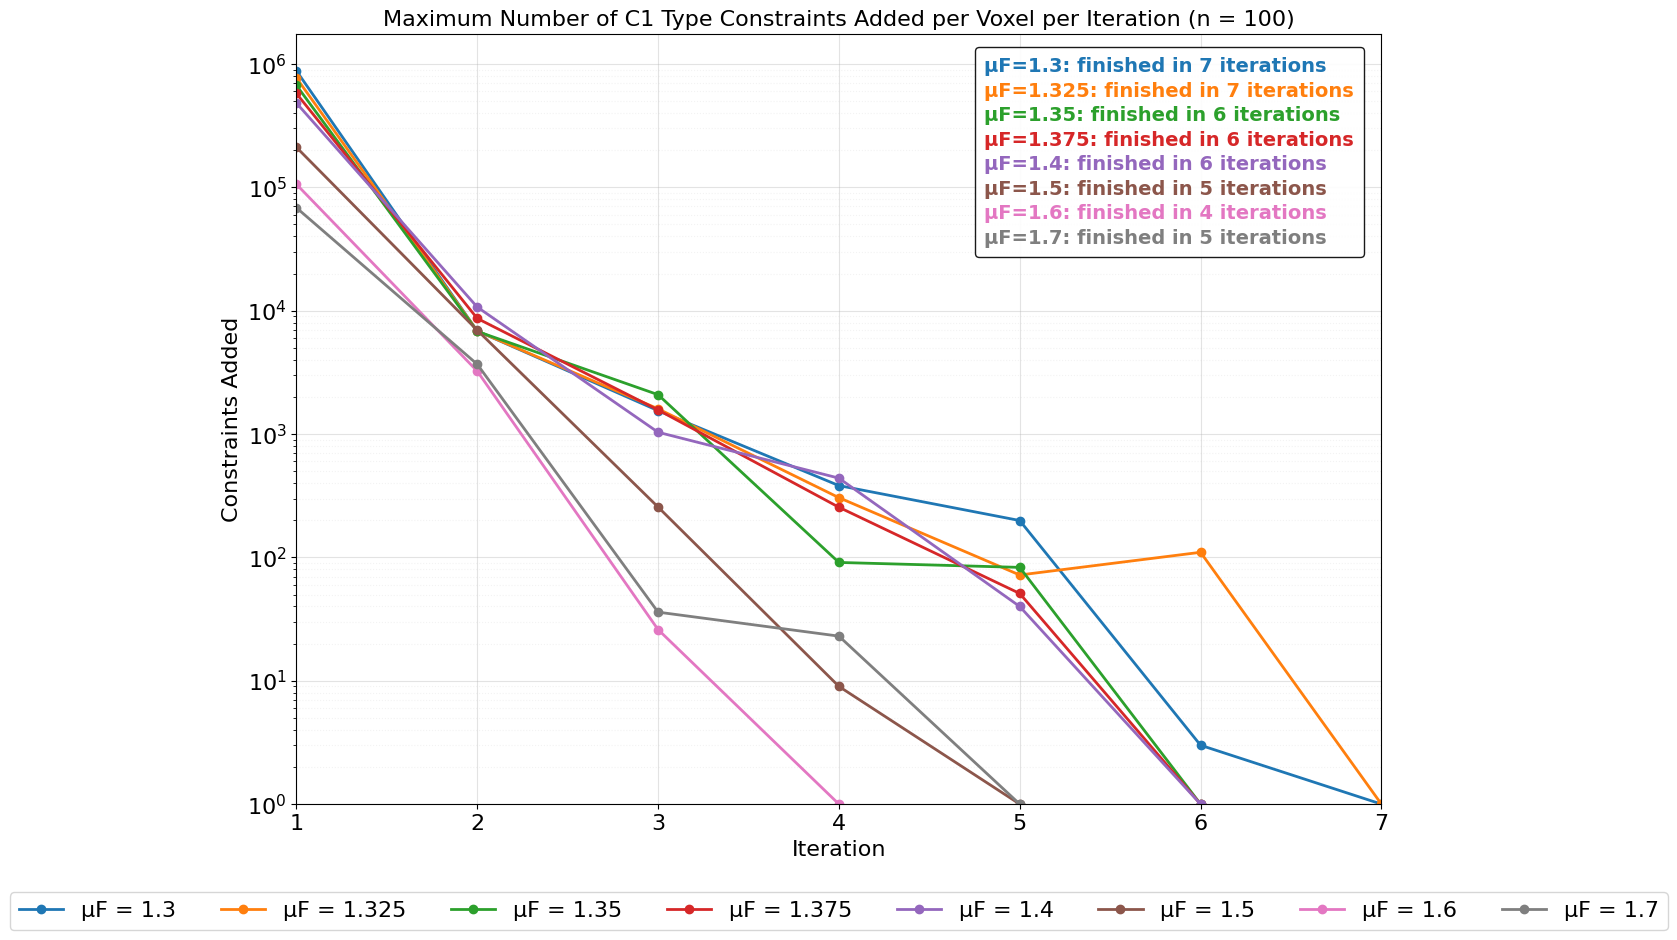

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, TextArea
from matplotlib.ticker import MaxNLocator

n_values = sorted(df['n_most_violated_constraints'].unique())
mu_F_values = sorted(df['mu_F'].unique())
mu_F_values = [mu_F for mu_F in mu_F_values if mu_F >= 1.3]


for n_val in n_values:
    fig, ax = plt.subplots(figsize=(14, 10))
    subset_n = df[df['n_most_violated_constraints'] == n_val]

    text_lines = []
    pos_min_vals = []
    max_len = 1

    for mu_F in mu_F_values:
        subset_mu = subset_n[subset_n['mu_F'] == mu_F]
        if not subset_mu.empty:
            constraints = np.array(subset_mu['c1_constraints_added_per_iteration'].iloc[0], dtype=float)
            iterations = np.arange(1, len(constraints) + 1)
            max_len = max(max_len, len(constraints))

            # Add 1 to zero or negative values for log scale plotting
            constraints = np.where(constraints <= 0, constraints + 1, constraints)

            pos_min_vals.append(constraints.min())

            line, = ax.plot(iterations, constraints, 'o-', linewidth=2, markersize=6,
                            label=f'μF = {mu_F}')
            text_lines.append((f'μF={mu_F}: finished in {len(iterations)} iterations',
                               line.get_color()))

    # Build legend box with per-line colors
    children = [
        TextArea(t, textprops=dict(color=c, fontsize=14, fontweight='bold'))
        for t, c in text_lines
    ]
    vbox = VPacker(children=children, align="left", pad=0, sep=4)
    anchored = AnchoredOffsetbox(
        loc='upper right', child=vbox, pad=0.4, borderpad=0.4,
        bbox_to_anchor=(0.985, 0.985), bbox_transform=ax.transAxes, frameon=True
    )
    anchored.patch.set_facecolor('white')
    anchored.patch.set_edgecolor('black')
    anchored.patch.set_alpha(0.9)
    anchored.patch.set_boxstyle("round,pad=0.3")
    ax.add_artist(anchored)

    # Axis setup
    ax.set_xlabel('Iteration', fontsize=16)
    ax.set_ylabel('Constraints Added', fontsize=16)
    ax.set_title(f'Maximum Number of C1 Type Constraints Added per Voxel per Iteration (n = {n_val})', fontsize=16)
    ax.set_yscale('log')
    if pos_min_vals:
        ax.set_ylim(bottom=max(1, min(pos_min_vals) * 0.9))
    ax.grid(True, which='major', alpha=0.35)
    ax.grid(True, which='minor', alpha=0.15, linestyle=':')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(left=1, right=max_len)
    ax.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(mu_F_values))

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.savefig(f'plots/c1_constraints_added_per_iteration_n_{n_val}.png',
                bbox_inches='tight', pad_inches=0.1)
    plt.show()


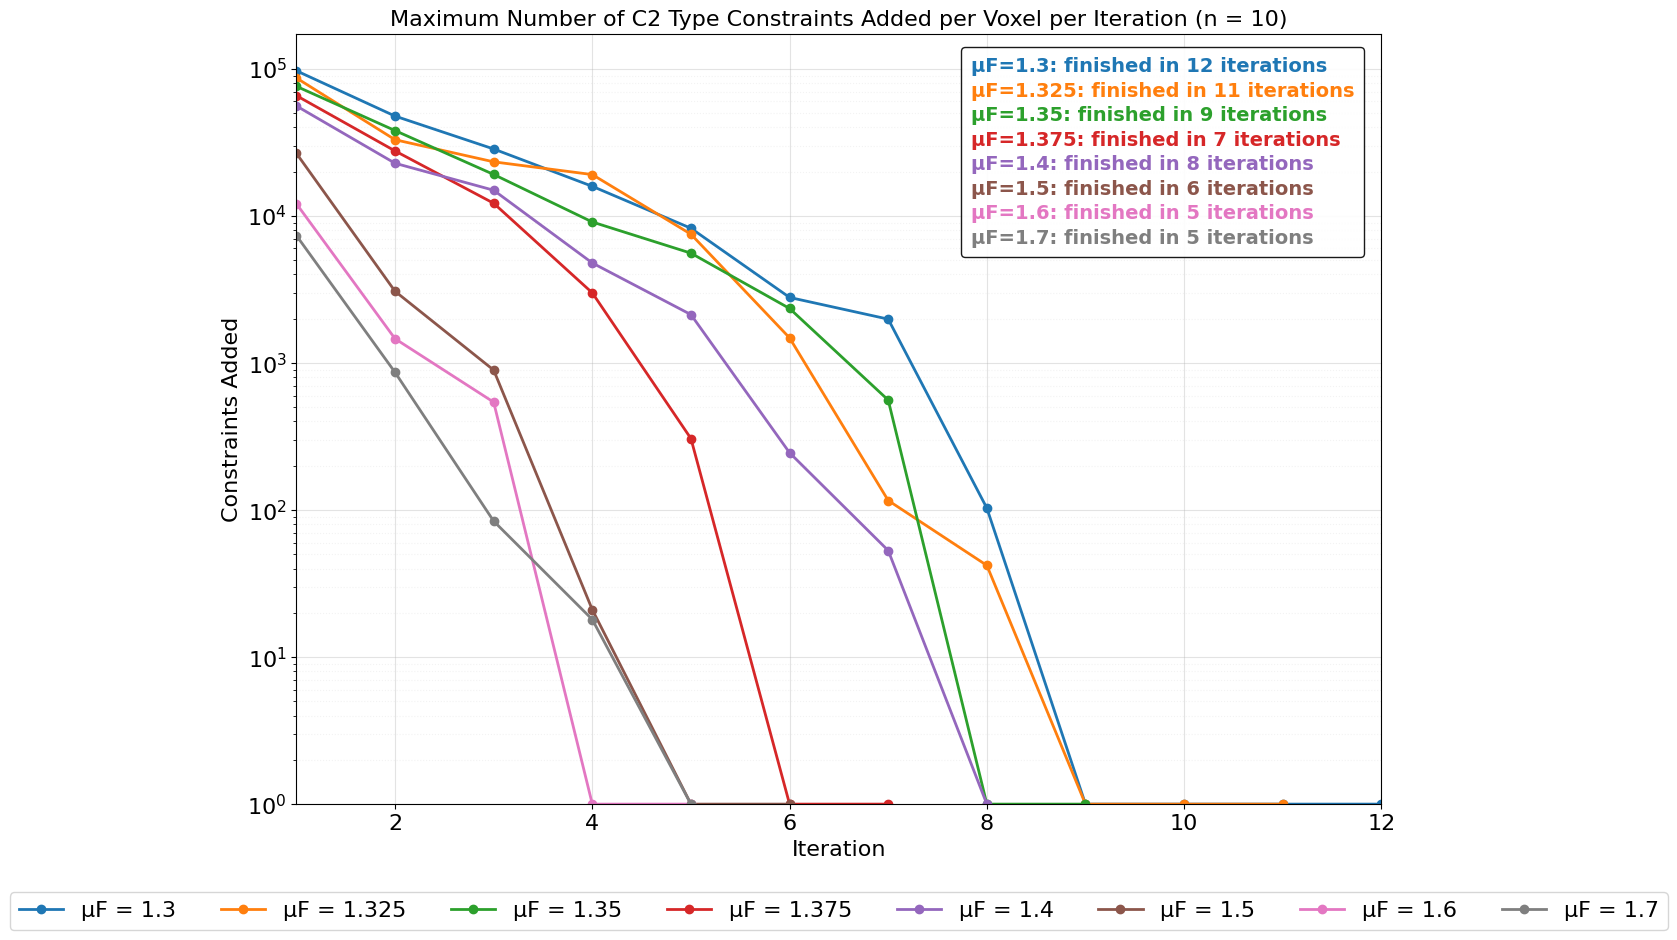

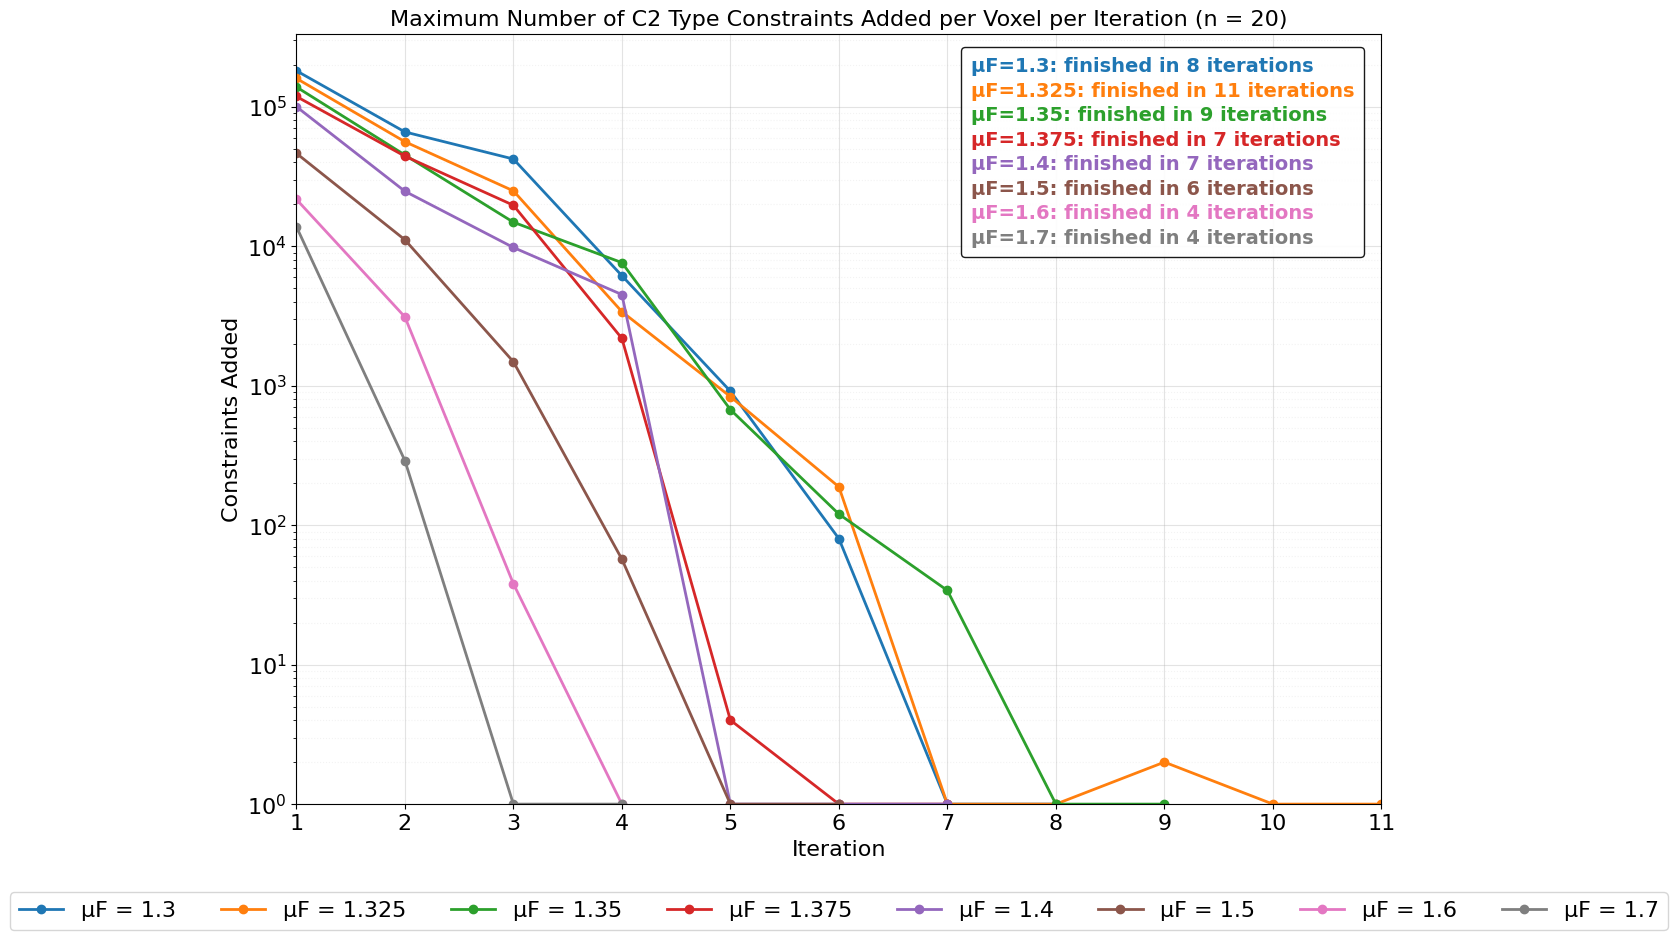

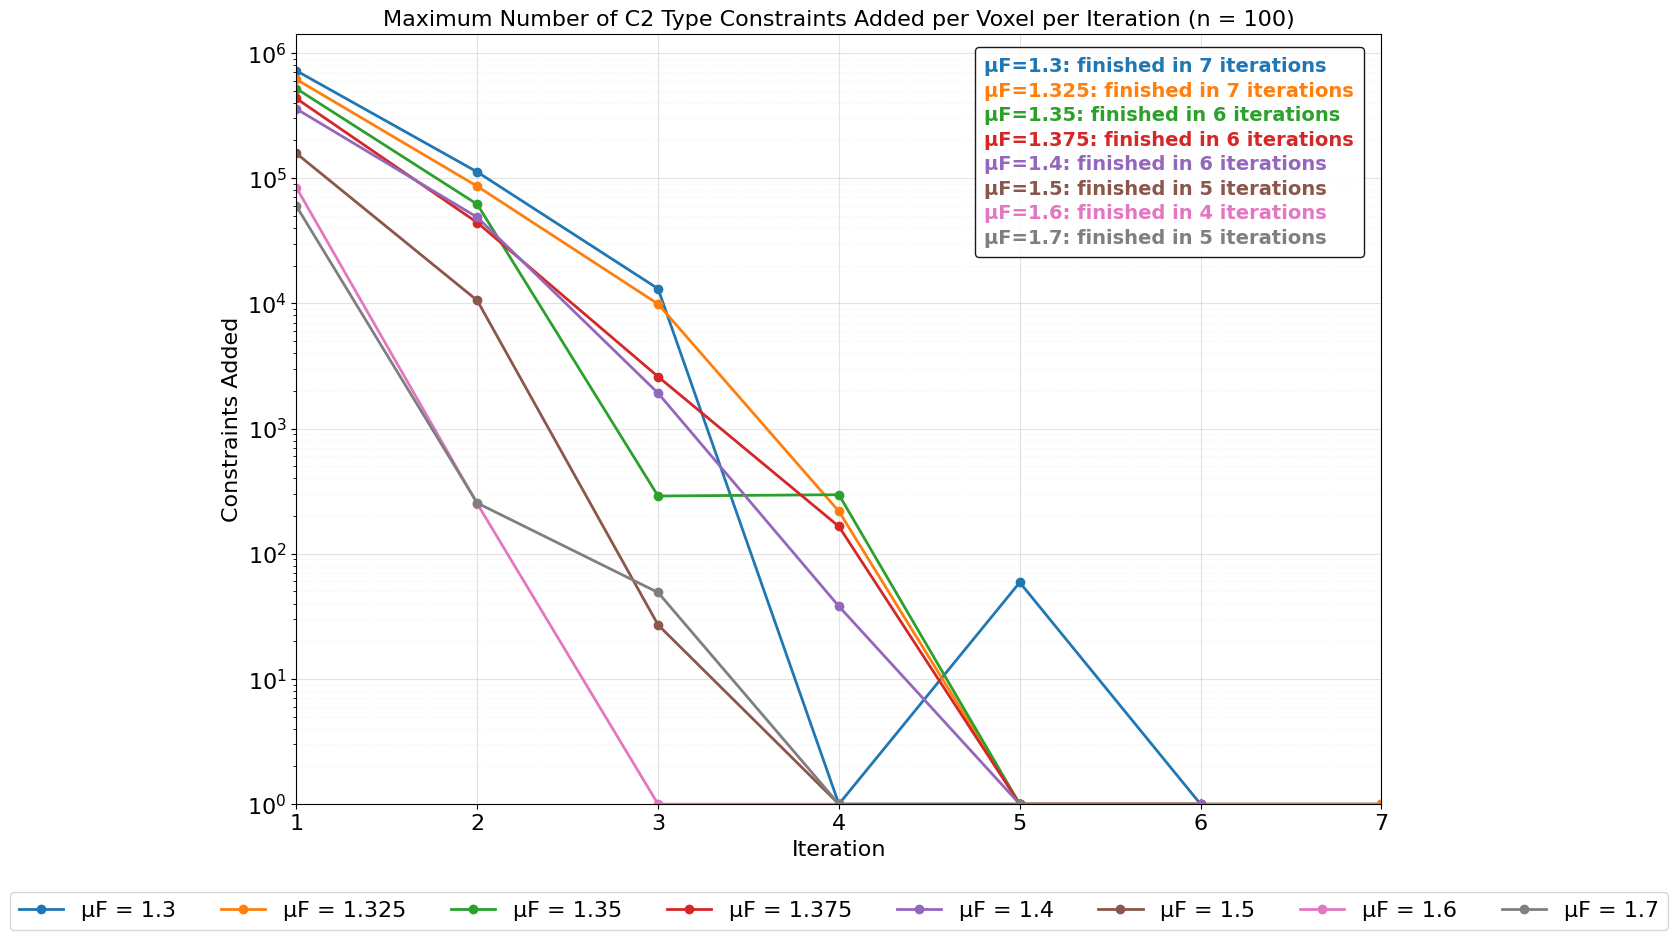

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, TextArea
from matplotlib.ticker import MaxNLocator

n_values = sorted(df['n_most_violated_constraints'].unique())
mu_F_values = sorted(df['mu_F'].unique())
mu_F_values = [mu_F for mu_F in mu_F_values if mu_F >= 1.3]


for n_val in n_values:
    fig, ax = plt.subplots(figsize=(14, 10))
    subset_n = df[df['n_most_violated_constraints'] == n_val]

    text_lines = []
    pos_min_vals = []
    max_len = 1

    for mu_F in mu_F_values:
        subset_mu = subset_n[subset_n['mu_F'] == mu_F]
        if not subset_mu.empty:
            constraints = np.array(subset_mu['c2_constraints_added_per_iteration'].iloc[0], dtype=float)
            iterations = np.arange(1, len(constraints) + 1)
            max_len = max(max_len, len(constraints))

            # Add 1 to zero or negative values for log scale plotting
            constraints = np.where(constraints <= 0, constraints + 1, constraints)

            pos_min_vals.append(constraints.min())

            line, = ax.plot(iterations, constraints, 'o-', linewidth=2, markersize=6,
                            label=f'μF = {mu_F}')
            text_lines.append((f'μF={mu_F}: finished in {len(iterations)} iterations',
                               line.get_color()))

    # Build legend box with per-line colors
    children = [
        TextArea(t, textprops=dict(color=c, fontsize=14, fontweight='bold'))
        for t, c in text_lines
    ]
    vbox = VPacker(children=children, align="left", pad=0, sep=4)
    anchored = AnchoredOffsetbox(
        loc='upper right', child=vbox, pad=0.4, borderpad=0.4,
        bbox_to_anchor=(0.985, 0.985), bbox_transform=ax.transAxes, frameon=True
    )
    anchored.patch.set_facecolor('white')
    anchored.patch.set_edgecolor('black')
    anchored.patch.set_alpha(0.9)
    anchored.patch.set_boxstyle("round,pad=0.3")
    ax.add_artist(anchored)

    # Axis setup
    ax.set_xlabel('Iteration', fontsize=16)
    ax.set_ylabel('Constraints Added', fontsize=16)
    ax.set_title(f'Maximum Number of C2 Type Constraints Added per Voxel per Iteration (n = {n_val})', fontsize=16)
    ax.set_yscale('log')
    if pos_min_vals:
        ax.set_ylim(bottom=max(1, min(pos_min_vals) * 0.9))
    ax.grid(True, which='major', alpha=0.35)
    ax.grid(True, which='minor', alpha=0.15, linestyle=':')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(left=1, right=max_len)
    ax.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(mu_F_values))

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.savefig(f'plots/c2_constraints_added_per_iteration_n_{n_val}.png',
                bbox_inches='tight', pad_inches=0.1)
    plt.show()
